# EconomIA — Preparación del dataset para clasificar transacciones

## Paso 3 del proyecto

Este notebook prepara el dataset de texto que se utilizará para entrenar el primer modelo de Machine Learning de Econom-AI

El objetivo de este MVP es:

```text
descripción de una transacción
            ↓
clasificador
            ↓
categoría predicha
```

### Decisiones de esta etapa

- La entrada principal será `descripcion`.
- La variable objetivo será `categoria`.
- `subcategoria` se conserva únicamente como información de apoyo.
- No se utilizan todavía `monto`, `fecha`, `metodo_pago` ni `recurrente`.
- Se excluye `Ingreso` porque el alcance inicial es clasificar gastos y movimientos de salida.
- Se conservan `Deudas` y `Finanzas` como categorías propias.
- La separación entre entrenamiento, validación y prueba se realiza antes del aumento de texto.
- Variaciones de una misma descripción permanecen siempre en el mismo conjunto.

Esta última decisión evita que frases casi idénticas aparezcan en entrenamiento y prueba, lo que produciría métricas artificialmente altas.

In [ ]:
# ================
# LIBRERÍAS Y SEED
# ================

from pathlib import Path
import hashlib
import random
import re
import unicodedata

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

pd.set_option("display.max_colwidth", 100)


## 1. Cargar el dataset de transacciones

Buscamos primero la versión final del generador de transacciones. Si no la encuentra, utiliza `transactions.csv`.

**N.** La ruta flexible permite ejecutar el notebook tanto en Google Colab como en un entorno local


In [ ]:
# ==============
# UBICAR ARCHIVO
# ==============

def find_transactions_file():
    file_name = ["transactions.csv"]
    folders = [Path("/content"), Path("/mnt/data"), Path(".")]

    for folder in folders:
        for file_name in file_name:
            path = folder / file_name
            if path.exists():
                return path

    raise FileNotFoundError(
        "No se encontró el archivo de transacciones"
        "Sube transactions.csv"
    )


TRANSACTIONS_FILE = find_transactions_file()
OUTPUT_DIR = Path("/content") if Path("/content").exists() else Path("/mnt/data")

print("Archivo utilizado:", TRANSACTIONS_FILE)
print("Carpeta de salida:", OUTPUT_DIR)

Archivo utilizado: /content/transactions.csv
Carpeta de salida: /content


In [ ]:
# ============
# CARGAR DATOS
# ============

transactions_df = pd.read_csv(TRANSACTIONS_FILE)
required_columns = {"descripcion","categoria","subcategoria",}
missing_columns = required_columns - set(transactions_df.columns)

if missing_columns: raise ValueError(f"Faltan columnas necesarias: {sorted(missing_columns)}")

print("Dimensiones originales:", transactions_df.shape)
display(transactions_df.head())

Dimensiones originales: (90684, 16)


,transaction_id,user_id,fecha,periodo,descripcion,categoria,subcategoria,monto,tipo,metodo_pago,canal,recurrente,origen_generacion,mes,anio,nombre_mes
0,TRX_000000016,USR_00001,2025-01-02,2025-01,Mantenimiento de vivienda,Vivienda,Mantenimiento,528.53,Gasto,Tarjeta de crédito,App bancaria,False,variable,1,2025,Enero
1,TRX_000000011,USR_00001,2025-01-05,2025-01,Compra en tienda,Alimentación,Tiendas,862.89,Gasto,Transferencia,App bancaria,False,variable,1,2025,Enero
2,TRX_000000017,USR_00001,2025-01-05,2025-01,Compra en tienda,Alimentación,Tiendas,1560.17,Gasto,Tarjeta de débito,App bancaria,False,variable,1,2025,Enero
3,TRX_000000002,USR_00001,2025-01-07,2025-01,Renta mensual,Vivienda,Renta,10073.46,Gasto,Transferencia,App bancaria,True,recurrente,1,2025,Enero
4,TRX_000000005,USR_00001,2025-01-09,2025-01,Recibo de agua,Servicios,Agua,556.79,Gasto,Tarjeta de débito,Terminal,True,recurrente,1,2025,Enero


## 2. Definir el alcance del clasificador

El primer modelo no intentará clasificar todos los tipos de movimiento

Se trabajará con estas once categorías:

- Alimentación
- Transporte
- Salud
- Vivienda
- Educación
- Entretenimiento
- Servicios
- Compras
- Otros
- Deudas
- Finanzas

`Ingreso` se excluye porque el MVP está orientado a gastos, ahorro, inversión y deuda. Si en el futuro se desea clasificar cualquier movimiento bancario, puede añadirse una primera etapa que prediga el `tipo` del movimiento.


In [ ]:
# ==========
# CATEGORÍAS
# ==========

TARGET_CATEGORIES = ["Alimentación","Transporte","Salud","Vivienda","Educación",
                     "Entretenimiento","Servicios","Compras","Otros","Deudas","Finanzas"]

text_source_df = transactions_df[transactions_df["categoria"].isin(TARGET_CATEGORIES)][["descripcion", "categoria", "subcategoria"]].copy()

text_source_df["origen"] = "transactions"

present_categories = set(text_source_df["categoria"])
missing_categories = set(TARGET_CATEGORIES) - present_categories

print("Registros dentro del alcance:", len(text_source_df))
print("Categorías encontradas:", sorted(present_categories))
print("Categorías que no aparecen en el CSV:", sorted(missing_categories))

Registros dentro del alcance: 84149
Categorías encontradas: ['Alimentación', 'Compras', 'Deudas', 'Educación', 'Entretenimiento', 'Finanzas', 'Otros', 'Salud', 'Servicios', 'Transporte', 'Vivienda']
Categorías que no aparecen en el CSV: []


## 3. Diagnóstico del texto original

El dataset de transacciones contiene muchas filas repetidas porque una misma plantilla aparece en distintos usuarios y meses

Para un modelo basado solo en texto, repetir miles de veces `"Pago de internet"` no agrega nueva información lingüística. Además, si la misma frase aparece en entrenamiento y prueba, el modelo puede memorizarla.

Por eso se revisan:

- Cantidad de registros
- Cantidad de descripciones únicas
- Descripciones únicas por categoría
- Posibles frases asignadas a más de una categoría


In [ ]:
# ===================
# DIAGNÓSTICO INICIAL
# ===================

description_summary = (
    text_source_df.groupby("categoria")
    .agg(registros=("descripcion", "size"),descripciones_unicas=("descripcion", "nunique"))
    .reindex(TARGET_CATEGORIES, fill_value=0)
    .reset_index())

display(description_summary)

print("Registros repetidos aproximados:",len(text_source_df) - text_source_df["descripcion"].nunique())

,categoria,registros,descripciones_unicas
0,Alimentación,17262,16
1,Transporte,7892,13
2,Salud,5914,17
3,Vivienda,6874,8
4,Educación,3556,6
5,Entretenimiento,7789,13
6,Servicios,18822,7
7,Compras,6479,15
8,Otros,4260,10
9,Deudas,2504,8


Registros repetidos aproximados: 84030


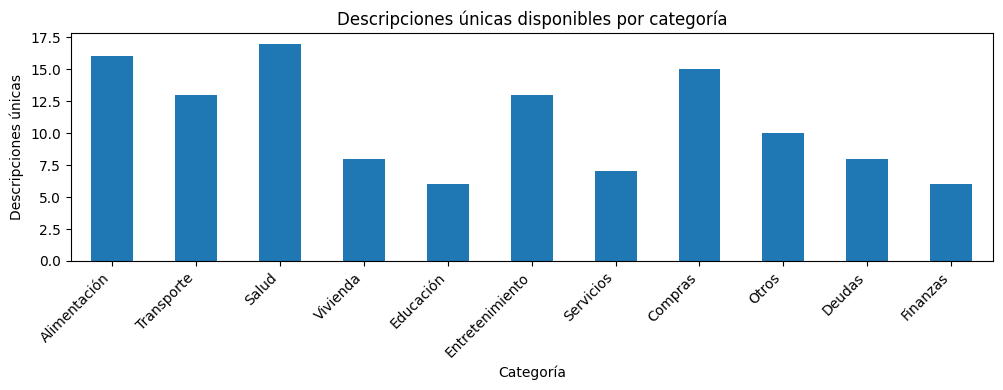

In [ ]:
# Gráfica de descripciones únicas por categoría

plot_data = description_summary.set_index("categoria")["descripciones_unicas"]

plt.figure(figsize=(10, 4))
plot_data.plot(kind="bar")
plt.title("Descripciones únicas disponibles por categoría")
plt.xlabel("Categoría")
plt.ylabel("Descripciones únicas")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 4. Normalización para control de duplicados

La normalización se utiliza para comparar textos, no para reemplazar obligatoriamente la descripción que verá el modelo

Ejemplo:

```text
"Pago de Teléfono"
"pago de telefono"
"pago   de teléfono"
```

Las tres frases deben reconocerse como una misma descripción base.

Por lo tanto, lo que hará esta función es:

- Convierte a minúsculas
- Elimina acentos
- Elimina signos
- Corrige espacios repetidos

In [ ]:
# ================
# NORMALIZAR TEXTO
# ================

def normalize_text(text):
    text = str(text).strip().lower()

    text = "".join(character
        for character in unicodedata.normalize("NFKD", text)
        if not unicodedata.combining(character))

    text = re.sub(r"[^a-z0-9ñ ]+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text

## 5. Agregar ejemplos controlados

El dataset actual tiene categorías con pocas frases diferentes y en versiones previas no incluímos `Deudas`. Por lo que, no se modifican las transacciones financieras originales. Se agrega un pequeño catálogo de ejemplos lingüísticos únicamente para preparar el clasificador de texto.

Estos ejemplos:

- Garantizan que `Deudas` y `Finanzas` estén
- Agregan expresiones abreviadas y cotidianas
- Aumentan la variedad sin inventar montos o balances
- Quedan identificados con `origen = catalogo_controlado`

In [ ]:
# ===================
# CATÁLOGO CONTROLADO
# ===================

EXTRA_EXAMPLES = {
    "Alimentación": [
        ("Supermercado", "super semanal"),
        ("Supermercado", "despensa quincenal"),
        ("Restaurante", "comida corrida"),
        ("Restaurante", "cena en restaurante"),
        ("Alimento para mascotas", "croquetas mascota"),
        ("Tiendas", "abarrotes de la esquina")
    ],
    "Transporte": [
        ("Uber", "uber a la oficina"),
        ("Combustible", "gasolina del auto"),
        ("Autobús", "pasaje de camión"),
        ("Servicio vehicular", "mantenimiento del coche"),
        ("Avión", "boleto de avión"),
        ("Taxi", "taxi al trabajo")
    ],
    "Salud": [
        ("Medicinas", "farmacia medicamentos"),
        ("Hospital", "consulta médica"),
        ("Laboratorios", "laboratorio clínico"),
        ("Dentista", "limpieza dental"),
        ("Óptica", "lentes en óptica"),
        ("Terapeuta", "sesión de terapia")
    ],
    "Vivienda": [
        ("Renta", "renta del departamento"),
        ("Hipoteca", "pago hipotecario"),
        ("Mantenimiento", "reparación de la casa"),
        ("Predial", "pago predial anual"),
        ("Muebles", "muebles para el hogar"),
        ("Electrodomésticos", "electrodoméstico para casa")
    ],
    "Educación": [
        ("Universidad", "colegiatura universidad"),
        ("Cursos", "curso online"),
        ("Cursos", "capacitación de trabajo"),
        ("Papelería", "papelería para escuela"),
        ("Material escolar", "libros de estudio"),
        ("Material escolar", "material para clase")
    ],
    "Entretenimiento": [
        ("Suscripciones", "netflix mensual"),
        ("Cine", "entrada al cine"),
        ("Conciertos", "boletos de concierto"),
        ("Videojuegos", "compra de videojuego"),
        ("Museos", "museo fin de semana"),
        ("Deportes", "inscripción gym")
    ],
    "Servicios": [
        ("Electricidad", "recibo cfe"),
        ("Internet", "internet de casa"),
        ("Teléfono", "plan de celular"),
        ("Agua", "recibo del agua"),
        ("Gas", "relleno tanque de gas"),
        ("TV de paga", "servicio de televisión")
    ],
    "Compras": [
        ("Ropa", "ropa en tienda"),
        ("Calzado", "zapatos nuevos"),
        ("Regalos", "regalo de cumpleaños"),
        ("Electrónica", "audífonos nuevos"),
        ("Accesorios", "accesorios personales"),
        ("Mascotas", "accesorios para mascota")
    ],
    "Otros": [
        ("Estacionamiento", "estacionamiento de plaza"),
        ("Donaciones", "donativo mensual"),
        ("Lavandería", "servicio de lavandería"),
        ("Tintorería", "ropa en tintorería"),
        ("Otros", "gasto sin clasificar"),
        ("Otros", "pago varios")
    ],
    "Finanzas": [
        ("Ahorro", "transferencia a ahorro"),
        ("Ahorro", "fondo de emergencia"),
        ("Inversiones", "inversión en cetes"),
        ("Inversiones", "compra de fondo de inversión"),
        ("Ahorro", "ahorro quincenal"),
        ("Inversiones", "inversión mensual")
    ],
    "Deudas": [
        ("Pago de tarjeta", "pago de tarjeta de crédito"),
        ("Pago de tarjeta", "abono a tdc"),
        ("Pago de tarjeta", "pago mensual de tarjeta"),
        ("Pago de préstamo", "pago de préstamo personal"),
        ("Pago de préstamo", "abono a crédito coche"),
        ("Pago de préstamo", "mensualidad del préstamo"),
        ("Pago de préstamo", "pago de crédito"),
        ("Nuevo crédito", "nuevo crédito"),
        ("Nuevo crédito", "financiamiento del mes"),
        ("Impuestos", "pago de impuestos"),
        ("Pago de préstamo", "abono de deuda")
    ],
}


extra_rows = []

for category, examples in EXTRA_EXAMPLES.items():
    for subcategory, description in examples:
        extra_rows.append({
            "descripcion": description,
            "categoria": category,
            "subcategoria": subcategory,
            "origen": "catalogo_controlado",
        })

extra_examples_df = pd.DataFrame(extra_rows)

combined_examples_df = pd.concat([text_source_df, extra_examples_df],ignore_index=True,)

print("Ejemplos controlados agregados:", len(extra_examples_df))
print("Registros combinados:", len(combined_examples_df))

Ejemplos controlados agregados: 71
Registros combinados: 84220


## 6. Crear el catálogo de descripciones base

Primero se eliminan repeticiones exactas normalizadas. También se detectan descripciones ambiguas (una frase es ambigua cuando aparece asociada a más de una categoría). Con una entrada basada solo en texto, el modelo no podría resolver correctamente una contradicción de etiquetas.

Las frases ambiguas se exportan para revisión y se excluyen temporalmente del entrenamiento.


In [ ]:
# ========================
# CREAR DESCRIPCIONES BASE
# ========================

combined_examples_df["descripcion_original"] = (combined_examples_df["descripcion"].astype(str).str.strip())
combined_examples_df["descripcion_normalizada"] = (combined_examples_df["descripcion_original"].apply(normalize_text))

label_count = (combined_examples_df.groupby("descripcion_normalizada")["categoria"].nunique())
ambiguous_texts = set(label_count[label_count > 1].index)
ambiguous_examples_df = combined_examples_df[combined_examples_df["descripcion_normalizada"].isin(ambiguous_texts)].copy()
clean_examples_df = combined_examples_df[~combined_examples_df["descripcion_normalizada"].isin(ambiguous_texts)].copy()

base_descriptions_df = (
    clean_examples_df
    .sort_values(["categoria", "descripcion_normalizada", "origen"])
    .drop_duplicates(["categoria", "descripcion_normalizada"])
    .reset_index(drop=True)
)

print("Descripciones ambiguas:", len(ambiguous_texts))
print("Descripciones base válidas:", len(base_descriptions_df))

Descripciones ambiguas: 0
Descripciones base válidas: 186


In [ ]:
# Crear un identificador estable para cada descripción base

def create_group_id(row):
    text = f"{row['categoria']}|{row['descripcion_normalizada']}"
    return hashlib.sha1(text.encode("utf-8")).hexdigest()[:12]


base_descriptions_df["grupo_descripcion"] = (base_descriptions_df.apply(create_group_id, axis=1))

base_summary = (
    base_descriptions_df.groupby("categoria")
    .agg(descripciones_base=("grupo_descripcion", "nunique"),
        ejemplos_desde_transacciones=("origen",lambda values: (values == "transactions").sum()),
        ejemplos_controlados=("origen",lambda values: (values == "catalogo_controlado").sum()))
    .reindex(TARGET_CATEGORIES, fill_value=0).reset_index())

display(base_summary)

,categoria,descripciones_base,ejemplos_desde_transacciones,ejemplos_controlados
0,Alimentación,22,16,6
1,Transporte,19,13,6
2,Salud,22,16,6
3,Vivienda,14,8,6
4,Educación,12,6,6
5,Entretenimiento,19,13,6
6,Servicios,13,7,6
7,Compras,21,15,6
8,Otros,16,10,6
9,Deudas,17,6,11


## 7. Separar entrenamiento, validación y prueba

La división se realiza por `grupo_descripcion`, no por fila. Esto significa que todas las variantes de una frase base quedan dentro del mismo conjunto.

Proporción aproximada:

```text
70 % entrenamiento
15 % validación
15 % prueba
```

Se realiza la división dentro de cada categoría para asegurar que las once clases estén representadas en los tres conjuntos.


In [ ]:
# ===========================
# ASIGNAR SPLIT POR CATEGORÍA
# ===========================

def assign_splits(base_df):
    assignments = {}

    for category, category_df in base_df.groupby("categoria"):
        group_ids = category_df["grupo_descripcion"].tolist()

        category_seed = SEED + sum(ord(character)for character in category)
        category_random = random.Random(category_seed)
        category_random.shuffle(group_ids)

        total_groups = len(group_ids)
        test_count = max(1, round(total_groups * 0.15))
        validation_count = max(1, round(total_groups * 0.15))

        # Deben quedar por lo menos dos grupos para entrenamiento
        while total_groups - test_count - validation_count < 2:
            if test_count > 1: test_count -= 1
            elif validation_count > 1: validation_count -= 1
            else:
              break

        test_groups = group_ids[:test_count]

        validation_groups = group_ids[test_count:test_count + validation_count]
        train_groups = group_ids[test_count + validation_count:]

        for group_id in train_groups:
            assignments[group_id] = "train"

        for group_id in validation_groups:
            assignments[group_id] = "validation"

        for group_id in test_groups:
            assignments[group_id] = "test"

    return assignments


split_assignments = assign_splits(base_descriptions_df)

base_descriptions_df["split"] = (base_descriptions_df["grupo_descripcion"].map(split_assignments))
split_base_summary = (base_descriptions_df.groupby(["categoria", "split"]).size().unstack(fill_value=0).reindex(TARGET_CATEGORIES))
display(split_base_summary)

split,test,train,validation
categoria,,,
Alimentación,3,16,3
Transporte,3,13,3
Salud,3,16,3
Vivienda,2,10,2
Educación,2,8,2
Entretenimiento,3,13,3
Servicios,2,9,2
Compras,3,15,3
Otros,2,12,2


## 8. Aumento controlado de texto

El aumento crea variantes similares a descripciones bancarias reales como:

- Minúsculas
- Texto sin acentos
- Abreviaturas
- Prefijos como `cargo`
- Año o frecuencia
- Errores ortográficos leves

No se generan nuevas etiquetas, cada variante conserva la categoría de su descripción base.

Se generan más variantes para entrenamiento que para validación y prueba:

```text
train:       hasta 5 variantes por descripción base
validation:  hasta 2 variantes
test:        hasta 2 variantes
```

El aumento se hace después del split para evitar fuga de información


In [ ]:
# ====================
# FUNCIONES DE AUMENTO
# ====================

ABBREVIATIONS = {
    "transferencia": "transf",
    "mensual": "mens",
    "tarjeta": "tdc",
    "credito": "cred",
    "crédito": "cred",
    "compra": "comp",
    "pago": "pg",
    "servicio": "serv",
    "universidad": "uni",
    "restaurante": "rest",
    "supermercado": "super",
    "mantenimiento": "mant",
    "estacionamiento": "estac",
    "inversion": "inv",
    "inversión": "inv",
    "prestamo": "prest",
    "préstamo": "prest",
}


def remove_accents(text):
    return "".join(
        character
        for character in unicodedata.normalize("NFKD", text)
        if not unicodedata.combining(character)
    )


def abbreviate_text(text):
    words = text.lower().split()

    abbreviated_words = [ABBREVIATIONS.get(word, word)for word in words]
    return " ".join(abbreviated_words)


def add_small_typo(text, seed):
    words = text.split()

    possible_positions = [index for index, word in enumerate(words)if len(word) >= 6]
    if not possible_positions: return text

    local_random = random.Random(seed)
    word_index = local_random.choice(possible_positions)
    word = words[word_index]
    character_index = local_random.randrange(1,len(word) - 1,)
    words[word_index] = (word[:character_index]+ word[character_index + 1:])
    return " ".join(words)


def create_text_variants(text, number_of_variants, group_id):
    clean_text = " ".join(str(text).strip().split())
    local_seed = int(group_id[:8], 16)

    candidates = [
        clean_text,
        clean_text.lower(),
        remove_accents(clean_text.lower()),
        abbreviate_text(clean_text),
        f"cargo {clean_text.lower()}",
        f"{clean_text.lower()} mensual",
        f"{clean_text.lower()} 2025",
        add_small_typo(clean_text.lower(), local_seed),
        clean_text.lower().replace(" ", "-"),
    ]

    variants = []
    normalized_variants = set()

    for candidate in candidates:
        normalized_candidate = normalize_text(candidate)

        if (normalized_candidate and normalized_candidate not in normalized_variants):
            variants.append(candidate)
            normalized_variants.add(normalized_candidate)

        if len(variants) == number_of_variants:break

    return variants

In [ ]:
# =======================
# CREAR DATASET AUMENTADO
# =======================

VARIANTS_PER_SPLIT = {"train": 5,"validation": 2,"test": 2,}
model_rows = []

for _, row in base_descriptions_df.iterrows():
    number_of_variants = VARIANTS_PER_SPLIT[row["split"]]

    variants = create_text_variants(
        text=row["descripcion_original"],
        number_of_variants=number_of_variants,
        group_id=row["grupo_descripcion"],
    )

    for variant in variants:
        model_rows.append({
            "descripcion_modelo": variant,
            "descripcion_original": row["descripcion_original"],
            "categoria": row["categoria"],
            "subcategoria": row["subcategoria"],
            "split": row["split"],
            "grupo_descripcion": row["grupo_descripcion"],
            "origen": row["origen"],
            "es_aumentada": variant != row["descripcion_original"],
            "texto_normalizado": normalize_text(variant),
        })

category_text_dataset = pd.DataFrame(model_rows)

print("Registros antes de revisar colisiones:", len(category_text_dataset))

Registros antes de revisar colisiones: 751


## 9. Eliminar colisiones entre conjuntos

Aunque las descripciones base están separadas, dos transformaciones podrían generar accidentalmente el mismo texto.

Por ejemplo:

```text
"Pago universidad"
"Universidad" + prefijo "pago"
```

Si una variante normalizada aparece en más de un split, se elimina para mantener una evaluación limpia


In [ ]:
# ==================
# REVISAR COLISIONES
# ==================

split_count_per_text = (category_text_dataset.groupby("texto_normalizado")["split"].nunique())

collision_texts = set(split_count_per_text[split_count_per_text > 1].index)

category_text_dataset = category_text_dataset[
    ~category_text_dataset["texto_normalizado"].isin(collision_texts)].copy()

category_text_dataset = (
    category_text_dataset
    .drop_duplicates(["texto_normalizado", "categoria", "split"])
    .sort_values(["split", "categoria", "grupo_descripcion"])
    .reset_index(drop=True)
)

print("Colisiones eliminadas:", len(collision_texts))
print("Registros finales:", len(category_text_dataset))

Colisiones eliminadas: 1
Registros finales: 748


## 10. Validaciones finales

Las validaciones comprueban que:

- Las once categorías existen
- Cada categoría aparece en train, validation y test
- Un grupo de descripción pertenece a un solo split
- Un texto normalizado pertenece a un solo split
- No hay valores nulos
- No se incluyó `Ingreso`
- `Deudas` y `Finanzas` están presentes


In [ ]:
# ============
# VALIDACIONES
# ============

def validate(condition, message):
    if not condition: raise ValueError(message)

validate(not category_text_dataset.empty, "No se generó el dataset de texto")
validate(category_text_dataset.isna().sum().sum() == 0,"Hay valores nulos")
validate(set(category_text_dataset["categoria"]) == set(TARGET_CATEGORIES),
    "No están presentes todas las categorías esperadas")

validate("Ingreso" not in set(category_text_dataset["categoria"]),"Ingreso no debe formar parte del MVP")
validate({"Deudas", "Finanzas"}.issubset(set(category_text_dataset["categoria"])),"Faltan Deudas o Finanzas")

categories_per_split = (category_text_dataset.groupby("split")["categoria"].nunique())
validate(categories_per_split.eq(len(TARGET_CATEGORIES)).all(),"No todos los splits contienen las once categorías")

group_split_count = (category_text_dataset.groupby("grupo_descripcion")["split"].nunique())
validate(group_split_count.max() == 1,"Un grupo de descripción aparece en más de un split")

text_split_count = (category_text_dataset.groupby("texto_normalizado")["split"].nunique())
validate(text_split_count.max() == 1,"Un texto aparece en más de un split")

print("Todas las validaciones fueron superadas.")

Todas las validaciones fueron superadas.


In [ ]:
# =====================
# REVISIÓN DEL DATASET
# =====================

category_text_audit = (
    category_text_dataset
    .groupby(["categoria", "split"])
    .agg(
        registros=("descripcion_modelo", "size"),
        descripciones_base=("grupo_descripcion", "nunique"),
        ejemplos_controlados=("origen",lambda values: (values == "catalogo_controlado").sum(),),
        ejemplos_aumentados=("es_aumentada","sum",)).reset_index())

display(category_text_audit.pivot(index="categoria",columns="split",values="registros",).fillna(0).astype(int).reindex(TARGET_CATEGORIES))

split,test,train,validation
categoria,,,
Alimentación,6,79,6
Transporte,6,61,6
Salud,6,80,6
Vivienda,4,50,4
Educación,4,38,4
Entretenimiento,6,64,6
Servicios,4,45,4
Compras,6,75,6
Otros,4,59,4


## 11. Exportar los productos

Se generan cuatro archivos:

| Archivo | Uso |
|---|---|
| `category_text_base_v1.csv` | Catálogo limpio de descripciones base |
| `category_text_dataset_v1.csv` | Dataset listo para modelado |
| `category_text_audit_v1.csv` | Distribución por categoría y split |
| `category_text_ambiguous_v1.csv` | Frases que requieren revisión |

En el siguiente paso del clasificador se utilizarán principalmente:

```text
descripcion_modelo → feature
categoria          → target
split              → separación ya definida
```

`subcategoria`, `origen` y `grupo_descripcion` se conservan meramente para revisión, pero no serán variables predictoras del primer modelo


In [ ]:
# ===========
# EXPORTACIÓN
# ===========

base_path = OUTPUT_DIR / "category_text_base_v1.csv"
dataset_path = OUTPUT_DIR / "category_text_dataset_v1.csv"
audit_path = OUTPUT_DIR / "category_text_audit_v1.csv"
ambiguous_path = OUTPUT_DIR / "category_text_ambiguous_v1.csv"

base_export_columns = [
    "descripcion_original",
    "descripcion_normalizada",
    "categoria",
    "subcategoria",
    "origen",
    "grupo_descripcion",
    "split",
]

dataset_export_columns = [
    "descripcion_modelo",
    "descripcion_original",
    "categoria",
    "subcategoria",
    "split",
    "grupo_descripcion",
    "origen",
    "es_aumentada",
    "texto_normalizado",
]

base_descriptions_df[base_export_columns].to_csv(base_path,index=False,encoding="utf-8-sig")
category_text_dataset[dataset_export_columns].to_csv(dataset_path,index=False,encoding="utf-8-sig")
category_text_audit.to_csv(audit_path,index=False,encoding="utf-8-sig")
ambiguous_examples_df.to_csv(ambiguous_path,index=False,encoding="utf-8-sig")

print("Archivos generados:")
print(base_path)
print(dataset_path)
print(audit_path)
print(ambiguous_path)

Archivos generados:
/content/category_text_base_v1.csv
/content/category_text_dataset_v1.csv
/content/category_text_audit_v1.csv
/content/category_text_ambiguous_v1.csv
